In [81]:
import zipfile

import numpy as np
import pandas as pd
from scipy.sparse import diags
from scipy.sparse.linalg import svds
from tqdm import tqdm

from dataprep import transform_indices, reindex_data, generate_interactions_matrix
from evaluation import downvote_seen_items, topn_recommendations

# getting data from Kaggle

In [82]:
competition_name = "skoltech-recommender-systems-challenge-2023"

In [83]:
!kaggle competitions download -c {competition_name}

zsh:1: command not found: kaggle


In [84]:
with zipfile.ZipFile("skoltech-recommender-systems-challenge-2023.zip","r") as z:
    z.extractall(".")

In [85]:
training_source = pd.read_csv('training')

In [86]:
testset_source = pd.read_csv('testset')

# Convenience functions

In [87]:
def plot_monthly_activity(data, ax=None, label=None, timeid='timestamp'):
    return (data
        .set_index(pd.to_datetime(data[timeid], unit='s'))
        .resample('M').size()
        .plot(ax=ax, logy=True, label=label, xlabel='Month',
              title='Monthly rating activity', legend=label is not None)
    )

## data splitting

In [88]:
def timepoint_split(data, time_split_q=0.95):
    """
    Split data into training, testset, and holdout datasets based on a timepoint split
    and according to the `warm-start` evaluation strategy.

    Parameters
    ----------
    data : pd.DataFrame
        The input dataset containing columns `userid`, `movieid`, and `timestamp`.
    time_split_q : float, optional
        The quantile value used to split the dataset based on the `timestamp` column.
        Default is 0.95.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
        A tuple of three pandas DataFrames: training, testset, and holdout.
        `training` is a subset of `data` used for training the recommender system.
        `testset` is a subset of `data` used for generating recommendations for the test users.
        `holdout` is a subset excluded from `testset` containing only the most recent interactions for each test user.

    Notes
    -----
    The function splits the input `data` into three subsets: `training`, `testset`, and `holdout`.
    The split is performed based on the `timestamp` column of `data`, using `time_split_q` as the quantile value.
    The `holdout` dataset contains only the immediate interactions following the fixed timepoint for each test user from the `testset`.
    The set of users in `training` is disjoint with the set of users in the `testset`, which implements the `warm-start` scenario.
    """    
    timepoint = data.timestamp.quantile(q=time_split_q, interpolation='nearest')
    test_ = data.query('timestamp >= @timepoint')
    rest_ = data.drop(test_.index)
    holdout_ = (
        test_
        .sort_values('timestamp')
        .drop_duplicates(subset=['userid'], keep='first')
    )
    # the holdout dataframe contains interactions closest to certain timepoint from the right,
    # i.e., the corresponding items are the first in each test user profile after this timepoint
    training = rest_.query('userid not in @holdout_.userid')
    train_items = training.movieid.unique()
    testset_ = rest_.query('userid in @holdout_.userid and movieid in @train_items')
    test_users = testset_.userid.unique()
    holdout = holdout_.query(
        # if user is not in `test_users` then no evluation is possible,
        # if item is not in `train_items` it's cold start -> must be excluded
        'userid in @test_users and movieid in @train_items'
    ).sort_values('userid')
    testset = testset_.query(
        # make sure testset and holdout contain the same set of users
        'userid in @holdout.userid'
    ).sort_values('userid')
    return training, testset, holdout

## kaggle solution format

In [89]:
def save_solution(recs_array, useridx, itemidx, filepath):
    """
    Save a solution for Kaggle competition in the required format.

    Parameters 
    ----------
    recs_array (numpy.ndarray): Array of recommended items. 
    useridx (pandas.Index): Test user indices in the original (source) representation. 
    itemidx (pandas.Index): Mapping from internal to orignial representation of item indices. 
    filepath (str): Path to save the solution file. 

    Returns
    -------
    None: The function saves the solution file in the csv format at the specified path. 

    Notes
    -----
    The code creates a dataframe containing user IDs and a list of recommended items for each user.
    It then melts the dataframe so that each row contains one recommended item per user.
    Finally, it saves the melted dataframe to a file at the specified filepath.
    """
    rec_items = itemidx.take(recs_array).values
    solution = pd.DataFrame({
        'userid': useridx,
        'movieid': [list(recs) for recs in rec_items]
    })
    sol_melt = solution.set_index('userid')['movieid'].explode().reset_index()
    sol_melt.to_csv(filepath, index=False)

To submit a solution, you can use he following command directly from a notebook cell:  

```
!kaggle competitions submit -c {competition_name} -f {filepath} -m 'my new submission'
```

# Evaluation setup

In [90]:
topn = 20

In [91]:
def evaluate(recommened_items, holdout, holdout_description, topn=10):
    itemid = holdout_description['items']
    holdout_items = holdout[itemid].values
    assert recommened_items.shape[0] == len(holdout_items)
    hits_mask = recommened_items[:, :topn] == holdout_items.reshape(-1, 1)
    #NDCG calculation
    n_test_users = recommened_items.shape[0]
    hit_rank = np.where(hits_mask)[1] + 1.0
    ndcg_pu = 1.0 / np.log2(hit_rank + 1)
    ndcg = np.sum(ndcg_pu) / n_test_users
    return ndcg

# Validation data preparation

In [92]:
testset_source.nunique()

userid          2963
movieid        17102
rating            10
timestamp    1346560
dtype: int64

In [93]:
train_val_, testset_val_, holdout_val_ = timepoint_split(training_source, time_split_q=0.96)

In [94]:
holdout_val_.shape

(1379, 4)

In [95]:
train_val, data_index = transform_indices(train_val_, 'userid', 'movieid')
testset_val = reindex_data(testset_val_, data_index, fields='items')
holdout_val = reindex_data(holdout_val_, data_index, fields='items')

In [96]:
assert not holdout_val['movieid'].eq(-1).any()

In [97]:
assert not testset_val['movieid'].eq(-1).any()

# 50 pts baseline

### grid-search

In [98]:
ranks = [b*2**n for n in range(3, 9) for b in [2, 3]]
ranks

[16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512, 768]

In [99]:
def build_svd_model(config, data, data_description):
    source_matrix = generate_interactions_matrix(data, data_description, rebase_users=False)
    *_, vt = svds(source_matrix, k=config['rank'], return_singular_vectors='vh')
    item_factors = np.ascontiguousarray(vt[::-1, :].T)
    return item_factors

def svd_model_scoring(params, data, data_description):
    item_factors = params
    test_matrix = generate_interactions_matrix(data, data_description, rebase_users=True) 
    scores = test_matrix.dot(item_factors) @ item_factors.T
    downvote_seen_items(scores, data, data_description)
    return scores

def svd_grid_search(ranks, training, testset, holdout, data_description, topn=20 ):
    max_rank = max(ranks)
    config = {'rank' : max_rank}
    item_factors = build_svd_model(config, training, data_description)
    results = {}
    for rank in tqdm(ranks):
        item_factors_trunc = item_factors[:, :rank]
        scores = svd_model_scoring(item_factors_trunc, testset, data_description)
        recs = topn_recommendations(scores, topn = topn)
        results[rank] = evaluate(recs, holdout, data_description)
    return results

In [100]:
data_description = dict(
    users = data_index['users'].name,
    items = data_index['items'].name,
    feedback = 'rating',
    n_users = len(data_index['users']),
    n_items = len(data_index['items']),
)

In [102]:
svd_results = svd_grid_search(
    ranks, train_val, testset_val , holdout_val, data_description, topn=topn
)

100%|██████████| 12/12 [00:07<00:00,  1.54it/s]


### best model

In [103]:
best_svd_rank = pd.Series(svd_results).idxmax()

In [104]:
best_svd_rank 

384

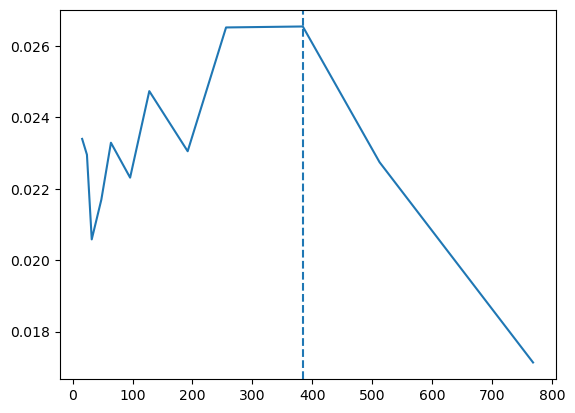

In [105]:
ax = pd.Series(svd_results).plot()
ax.axvline(best_svd_rank, ls='--')

In [106]:
def transform_data(train, test, holdout=None, userid='userid', itemid='movieid'):
    train_new, data_index = transform_indices(train, userid, itemid)
    testset_new = reindex_data(test, data_index, fields='items')
    if holdout is None:
        return train_new, testset_new, data_index
    holdout_new = reindex_data(holdout, data_index, fields='items')
    return train_new, testset_new, holdout_new, data_index

In [107]:
training, testset, data_index_source = transform_data(
    training_source, testset_source, userid = 'userid', itemid='movieid'
)

In [108]:
data_description_source = dict(
    users = data_index['users'].name,
    items = data_index['items'].name,
    feedback = 'rating',
    n_users = len(data_index_source['users']),
    n_items = len(data_index_source['items']), 
)

In [109]:
best_config = {'rank' : best_svd_rank}
item_factors = build_svd_model(best_config, training, data_description_source)
scores = svd_model_scoring(item_factors, testset, data_description_source)
recs = topn_recommendations(scores, topn=topn)

In [110]:
recs.shape

(2963, 20)

In [111]:
test_users_index = pd.Index(
    testset_source['userid'].drop_duplicates()
)
test_users_index

Int64Index([    55,    133,    136,    213,    539,    604,    718,   1029,
              1088,   1179,
            ...
            282326, 282382, 282402, 282420, 282522, 282663, 282836, 282999,
            283047, 283183],
           dtype='int64', name='userid', length=2963)

In [112]:
data_index_source['items']

Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            51754, 51820, 51828, 52155, 52362, 52386, 52492, 52509, 52993,
            53859],
           dtype='int64', name='movieid', length=18264)

In [ ]:
svd_sol_filepath = 'svd_recs.csv'
save_solution(recs, test_users_index, data_index_source['items'], svd_sol_filepath)

# 75 pts baseline

### grid-search

In [113]:
scalings = [0.2, 0.4, 0.6, 0.8]

In [114]:
def ssvd_grid_serch(ranks, scalings, training, testset, holdout, data_description, topn=20):
    max_rank = max(ranks)
    config = {'rank' : max_rank}
    results = {}
    for scaling in tqdm(scalings):
        config['scaling'] = scaling
        item_factors, *rest = build_ssvd_model(config, training, data_description)
        for rank in ranks:
            new_params = (item_factors[:, :rank],) + tuple(rest)
            scores = ssvd_model_scoring(new_params, testset, data_description)
            recs = topn_recommendations(scores, topn=topn)
            results[(rank, scaling)] = evaluate(recs, holdout, data_description)
    return results

def build_ssvd_model(config, data, data_description):
    source_matrix = generate_interactions_matrix(data, data_description, rebase_users=False)
    scaled_matrix, scaling_weights = rescale_matrix(source_matrix, config['scaling'])
    *_, vt = svds(scaled_matrix, k=config['rank'], return_singular_vectors='vh')
    item_factors = np.ascontiguousarray(vt[::-1, :].T)
    return item_factors, scaling_weights

def rescale_matrix(matrix, scaling_factor):
    frequentcies = matrix.getnnz(axis=0)
    scaling_weights = np.power(frequentcies, 0.5*(scaling_factor - 1))
    return matrix.dot(diags(scaling_weights)), scaling_weights

def ssvd_model_scoring(params, data, data_description):
    item_factors, scaling_weights = params
    test_matrix = generate_interactions_matrix(data, data_description, rebase_users=True)
    scores = test_matrix.dot(item_factors) @ item_factors.T
    downvote_seen_items(scores, data, data_description)
    return scores

In [115]:
ssvd_results = ssvd_grid_serch(
    ranks, scalings, 
    train_val, testset_val, holdout_val, 
    data_description, 
    topn=topn
    )

100%|██████████| 4/4 [21:25<00:00, 321.30s/it]


### best model

In [116]:
best_config = dict(
    zip(
        ['rank', 'scaling'],
        pd.Series(ssvd_results).idxmax()
    )
)
best_config

{'rank': 384, 'scaling': 0.4}

In [117]:
(
    pd.Series(ssvd_results)
    .unstack(level=1)
    .style.format("{:.4f}")
    .background_gradient(high=0.2, axis=None)
)

,0.200000,0.400000,0.600000,0.800000
16,0.0214,0.0223,0.0222,0.0224
24,0.0232,0.0239,0.0223,0.0240
32,0.0241,0.0246,0.0245,0.0242
48,0.0231,0.0244,0.0239,0.0233
64,0.0241,0.0252,0.0239,0.0260
96,0.0249,0.0249,0.0260,0.0276
128,0.0244,0.0280,0.0286,0.0271
192,0.0252,0.0281,0.0292,0.0249
256,0.0255,0.0305,0.0295,0.0257
384,0.0283,0.0329,0.0254,0.0277


In [118]:
ssvd_params = build_ssvd_model(best_config, training, data_description_source)
sscores = ssvd_model_scoring(ssvd_params, testset, data_description_source)
srecs = topn_recommendations(sscores, topn=topn)

In [119]:
svd_sol_filepath = 'ssvd_recs_new2.csv'
save_solution(srecs, test_users_index, data_index_source['items'], svd_sol_filepath)